In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# 1. Define where your zip file is in Drive
# Hint: If you just uploaded it to the main folder, it's likely here:
zip_path = '/content/drive/MyDrive/breast-cancer-gene-expression-cumida.zip'

# 2. Unzip into a local folder
!unzip "$zip_path" -d "/content/cumida_data"

# 3. Check the file name inside
print("Files found:", os.listdir("/content/cumida_data"))

Archive:  /content/drive/MyDrive/breast-cancer-gene-expression-cumida.zip
  inflating: /content/cumida_data/Breast_GSE45827.csv  
Files found: ['Breast_GSE45827.csv']


In [ ]:
import pandas as pd
import glob

# Find the CSV automatically (so exact filename doesn't matter)
csv_files = glob.glob('/content/cumida_data/*.csv')

if csv_files:
    file_path = csv_files[0]
    print(f"Loading: {file_path}")
    df = pd.read_csv(file_path)

    # Quick sanity check
    print(f"Data Shape: {df.shape}") # Should be approx (151, 54678)
    print("Classes:", df['type'].unique())
else:
    print("No CSV found! Check your zip file.")

Loading: /content/cumida_data/Breast_GSE45827.csv
Data Shape: (151, 54677)
Classes: ['basal' 'HER' 'cell_line' 'normal' 'luminal_A' 'luminal_B']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Load Data (assuming you unzipped it as discussed)
# Replace with your actual path if different
df = pd.read_csv('/content/cumida_data/Breast_GSE45827.csv')

# 2. Separate Target & Features
# 'type' is usually the target in CuMiDa, 'samples' is metadata
X = df.drop(['samples', 'type'], axis=1)
y = df['type']

# 3. Label Encoding (Target)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Classes found: {le.classes_}")

# 4. Train/Test Split (Stratified is crucial for small data!)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# --- BRANCH A: For Traditional & Transformer (Numerical) ---

# Step A1: Feature Selection (Reduce 54k -> 2k genes)
# We only fit this on TRAIN data to avoid data leakage
selector = SelectKBest(score_func=f_classif, k=10000)
selector.fit(X_train_raw, y_train)

# Get the names of the top genes (We need these for the LLM later!)
top_gene_names = X.columns[selector.get_support()]

# Transform the data
X_train_reduced = selector.transform(X_train_raw)
X_test_reduced = selector.transform(X_test_raw)

# Step A2: Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_test_scaled = scaler.transform(X_test_reduced)

print(f"Original Shape: {X_train_raw.shape}")
print(f"Processed Shape: {X_train_scaled.shape}")

# --- BRANCH B: For LLM (Text Serialization) ---

def serialize_row(row_values, feature_names):
    """Convert a row of gene values into a text description."""
    text_parts = []
    # We zip the gene names with their values
    for name, val in zip(feature_names, row_values):
        # We can simplify: is it positive (up-regulated) or negative?
        status = "high" if val > 0 else "low"
        text_parts.append(f"{name} is {status}")

    # Join first 50 genes to keep text length manageable for BERT
    return "Breast cancer profile: " + ", ".join(text_parts[:50]) + "."

# Apply to Train data
# Note: We use the REDUCED data so we only serialize important genes
X_train_text = [serialize_row(row, top_gene_names) for row in X_train_reduced]
X_test_text = [serialize_row(row, top_gene_names) for row in X_test_reduced]

print(f"LLM Example Input: {X_train_text[0][:100]}...")

Classes found: ['HER' 'basal' 'cell_line' 'luminal_A' 'luminal_B' 'normal']
Original Shape: (120, 54675)
Processed Shape: (120, 10000)
LLM Example Input: Breast cancer profile: 1053_at is high, 117_at is high, 1487_at is high, 1552263_at is high, 1552264...


In [ ]:
# 1. Install the library

!pip install pytorch-tabnet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.5 MB/s eta 0:00:00


✅ GPU Detected: Tesla T4
Training TabNet on 10000 features (GPU)...


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 2.74225 | train_accuracy: 0.24167 | valid_accuracy: 0.22581 |  0:00:01s
epoch 1  | loss: 2.39631 | train_accuracy: 0.19167 | valid_accuracy: 0.19355 |  0:00:01s
epoch 2  | loss: 2.19843 | train_accuracy: 0.19167 | valid_accuracy: 0.22581 |  0:00:01s
epoch 3  | loss: 2.03757 | train_accuracy: 0.19167 | valid_accuracy: 0.19355 |  0:00:01s
epoch 4  | loss: 1.8484  | train_accuracy: 0.19167 | valid_accuracy: 0.19355 |  0:00:02s
epoch 5  | loss: 1.88277 | train_accuracy: 0.19167 | valid_accuracy: 0.19355 |  0:00:02s
epoch 6  | loss: 1.82522 | train_accuracy: 0.19167 | valid_accuracy: 0.19355 |  0:00:02s
epoch 7  | loss: 1.71197 | train_accuracy: 0.2     | valid_accuracy: 0.19355 |  0:00:02s
epoch 8  | loss: 1.66536 | train_accuracy: 0.2     | valid_accuracy: 0.19355 |  0:00:02s
epoch 9  | loss: 1.65839 | train_accuracy: 0.225   | valid_accuracy: 0.19355 |  0:00:02s
epoch 10 | loss: 1.60279 | train_accuracy: 0.21667 | valid_accuracy: 0.19355 |  0:00:03s
epoch 11 | loss: 1.52

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


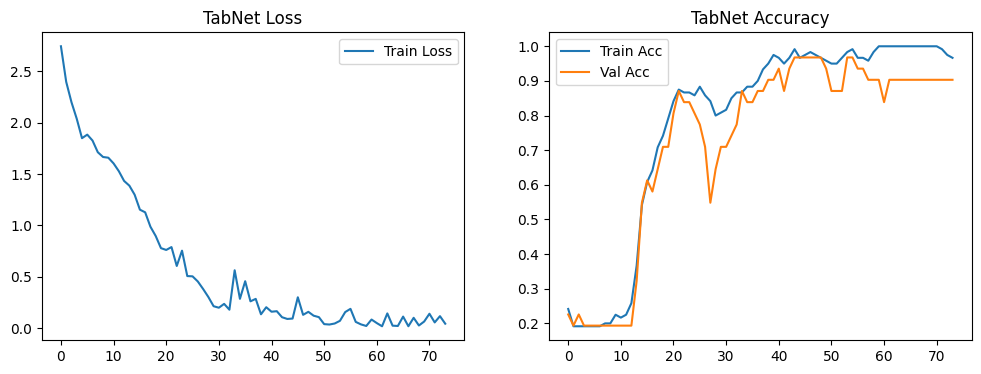

In [ ]:

import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Verify GPU availability
if torch.cuda.is_available():
    print(f"✅ GPU Detected: {torch.cuda.get_device_name(0)}")
    device = 'cuda'
else:
    print("⚠️ GPU not found. Using CPU.")
    device = 'cpu'

# 2. Configure TabNet with GPU Support & High-Dim Settings
clf_tabnet = TabNetClassifier(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size": 20, "gamma": 0.9}, # Slower decay for larger feature set
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax',
    lambda_sparse=1e-3,  # <--- CRITICAL: Penalizes using too many features (helps with 10k cols)
    device_name=device,
    verbose=1
)

# 3. Train
print(f"Training TabNet on {X_train_scaled.shape[1]} features (GPU)...")

clf_tabnet.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    eval_name=['train', 'valid'],
    eval_metric=['accuracy'],
    max_epochs=200,      # Increased from 100: Needs more time to scan 10k features
    patience=30,         # Increased patience
    batch_size=64,       # Reduced: 10k cols is "wide", smaller batches help generalization
    virtual_batch_size=32,
    num_workers=0,
    drop_last=False
)

# 4. Predict
y_pred_tab = clf_tabnet.predict(X_test_scaled)

# 5. Evaluate
acc_tab = accuracy_score(y_test, y_pred_tab)
print(f"\n✅ TabNet Accuracy (10k features): {acc_tab:.4f}")

# 6. Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(clf_tabnet.history['loss'], label='Train Loss')
plt.title('TabNet Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(clf_tabnet.history['train_accuracy'], label='Train Acc')
plt.plot(clf_tabnet.history['valid_accuracy'], label='Val Acc')
plt.title('TabNet Accuracy')
plt.legend()
plt.show()

Generating TabNet predictions...


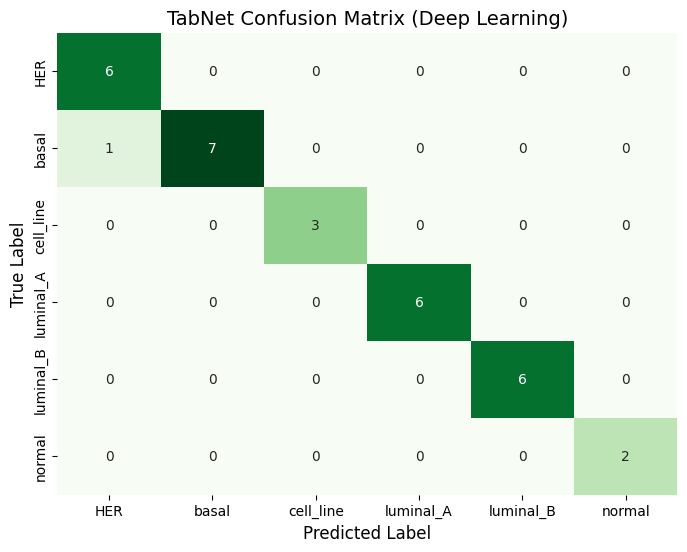

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Get Predictions
print("Generating TabNet predictions...")
y_pred_tab = clf_tabnet.predict(X_test_scaled)

# 2. Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tab)

# 3. Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('TabNet Confusion Matrix (Deep Learning)', fontsize=14)
plt.show()

✅ TabNet Precision & Recall Report:

              precision    recall  f1-score   support

         HER       0.86      1.00      0.92         6
       basal       1.00      0.88      0.93         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       1.00      1.00      1.00         6
   luminal_B       1.00      1.00      1.00         6
      normal       1.00      1.00      1.00         2

    accuracy                           0.97        31
   macro avg       0.98      0.98      0.98        31
weighted avg       0.97      0.97      0.97        31



/tmp/ipython-input-343751732.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


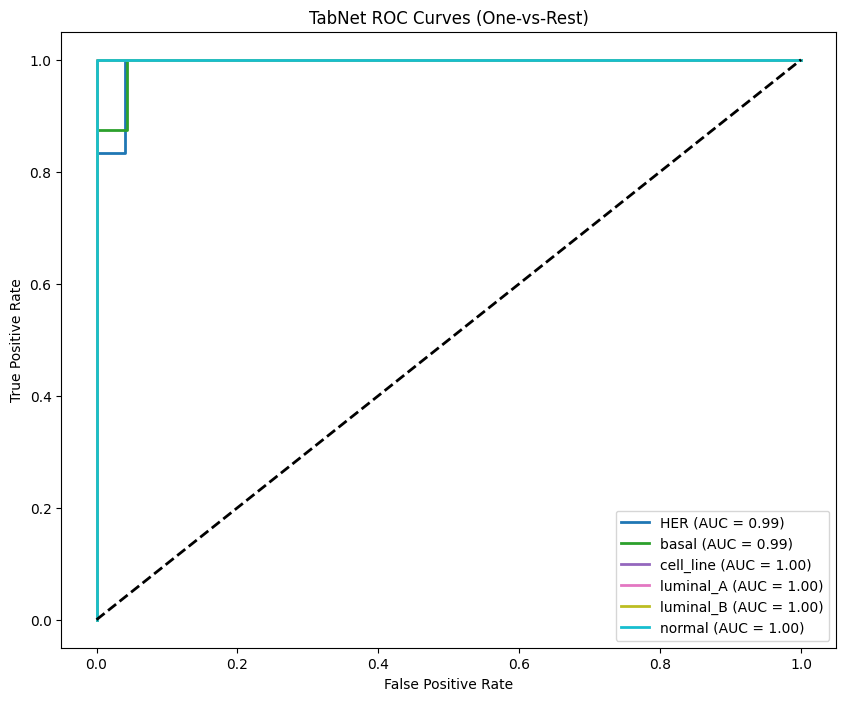

In [ ]:
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Get Probabilities ---
y_probs = clf_tabnet.predict_proba(X_test_scaled)
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

# --- 2. Print Precision/Recall Values ---
print("✅ TabNet Precision & Recall Report:\n")
print(classification_report(y_test, clf_tabnet.predict(X_test_scaled), target_names=le.classes_))

# --- 3. Plot ROC Curve ---
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors(i), lw=2,
             label=f'{le.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('TabNet ROC Curves (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()